In [72]:
# IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [73]:
# LOAD DATA

print("=== LOAD DATA ===")
df = pd.read_csv('creditcard.csv')

print("Shape data:", df.shape)
print("\nInfo data:")
print(df.info())


=== LOAD DATA ===
Shape data: (284807, 31)

Info data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float6

In [74]:
# Mengidentifikasi Missing Values, duplikat pada data, dan statistik Deskriptif pada dataset

print("\n=== Missing values, outliers, statistik deskriptif ===")

# Missing values
missing_values = df.isnull().sum()
print("Total Missing:", missing_values.sum())

# Duplicate
duplicate_count = df.duplicated().sum()
print("\nJumlah Duplikasi:", duplicate_count)

# Statistik
print("\nStatistik Deskriptif:")
print(df.describe())



=== Missing values, outliers, statistik deskriptif ===
Total Missing: 0

Jumlah Duplikasi: 1081

Statistik Deskriptif:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
m


=== VISUALISASI AWAL ===


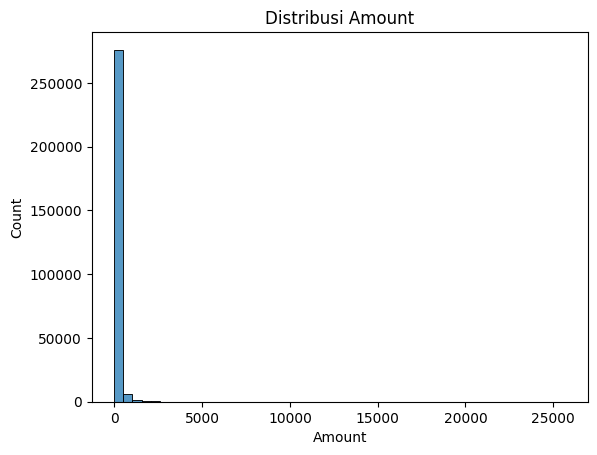

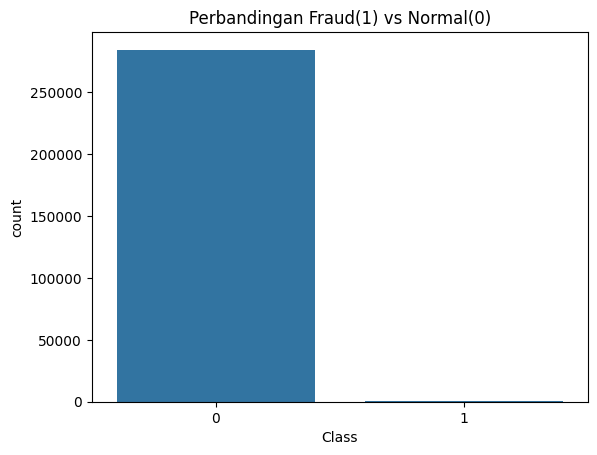


=== HEATMAP ===


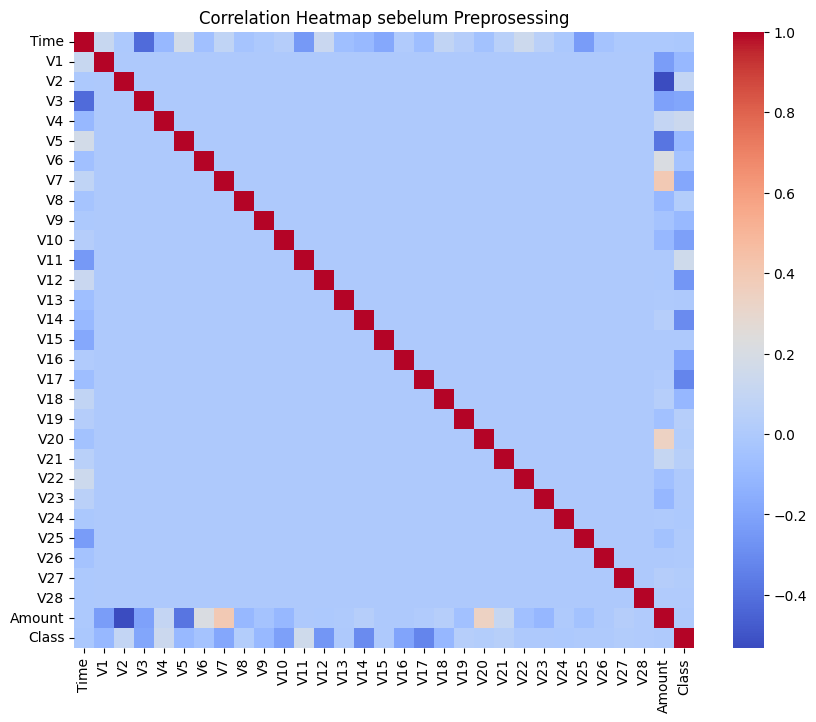

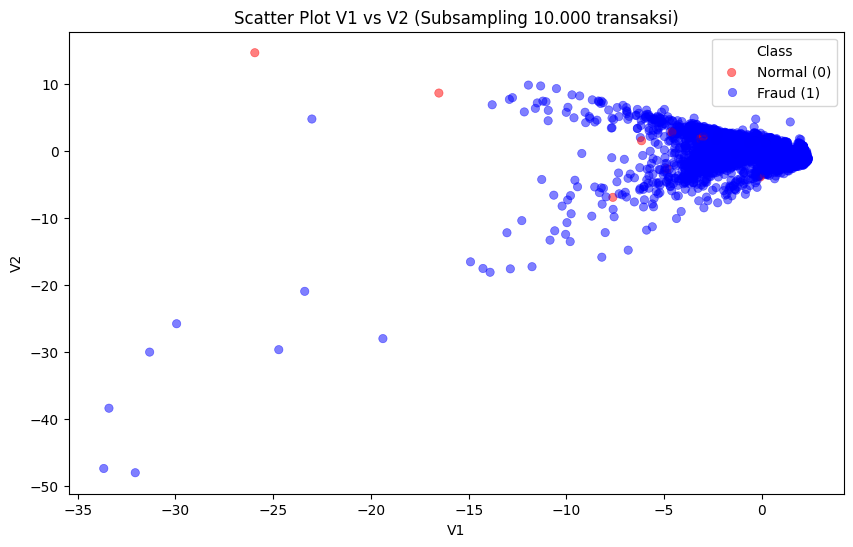

In [75]:
# VISUALISASI AWAL

print("\n=== VISUALISASI AWAL ===")

# Distribusi Amount
plt.figure()
sns.histplot(df['Amount'], bins=50)
plt.title("Distribusi Amount")
plt.show()


#Histogram Perbandingan Fraud dan normal
plt.figure()
sns.countplot(x='Class', data=df)
plt.title("Perbandingan Fraud(1) vs Normal(0)")
plt.show()


# HEATMAP KORELASI
print("\n=== HEATMAP ===")

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap sebelum Preprosessing")
plt.show()


# Scatter Plot (Outlier)
df_sample = df.sample(n=10000, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='V1', y='V2', hue='Class',
                palette={0: 'blue', 1: 'red'}, alpha=0.5, edgecolor=None)
plt.title('Scatter Plot V1 vs V2 (Subsampling 10.000 transaksi)')
plt.legend(title='Class', labels=['Normal (0)', 'Fraud (1)'])
plt.show()



In [76]:
# DATA CLEANING

print("\n=== DATA CLEANING ===")

# Hapus duplikasi
print("Sebelum hapus duplikasi:", df.shape)
df = df.drop_duplicates()
print("Setelah hapus duplikasi:", df.shape)


# HANDLE OUTLIER (IQR)
print("\n=== HANDLE OUTLIER (IQR) ===")

Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Sebelum Outliers dihapus:{df.shape}')

df = df[(df['Amount'] >= lower_bound) & (df['Amount'] <= upper_bound)]

print("Setelah hapus outlier:", df.shape)




=== DATA CLEANING ===
Sebelum hapus duplikasi: (284807, 31)
Setelah hapus duplikasi: (283726, 31)

=== HANDLE OUTLIER (IQR) ===
Sebelum Outliers dihapus:(283726, 31)
Setelah hapus outlier: (252041, 31)


In [77]:
# PREPROCESSING
scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop kolom lama
df = df.drop(['Amount', 'Time'], axis=1)



=== VISUALISASI SETELAH PREPROCESSING ===


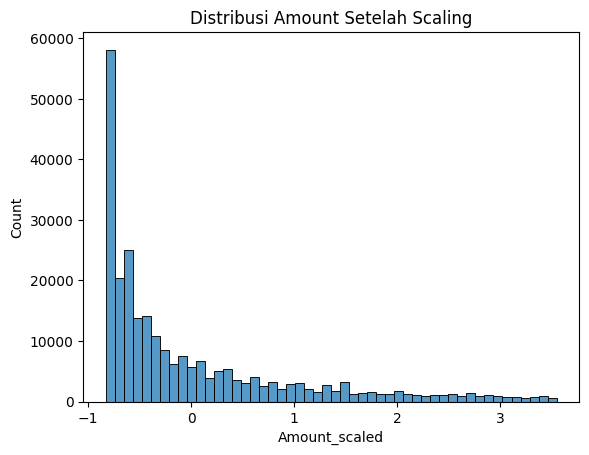


=== Perbandingan Fraud dan normal ===


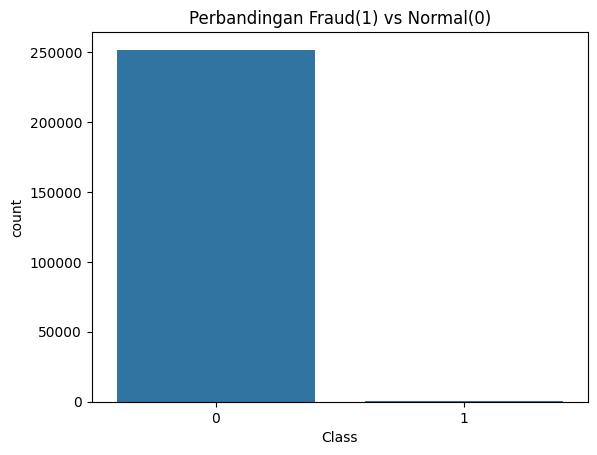


=== HEATMAP ===


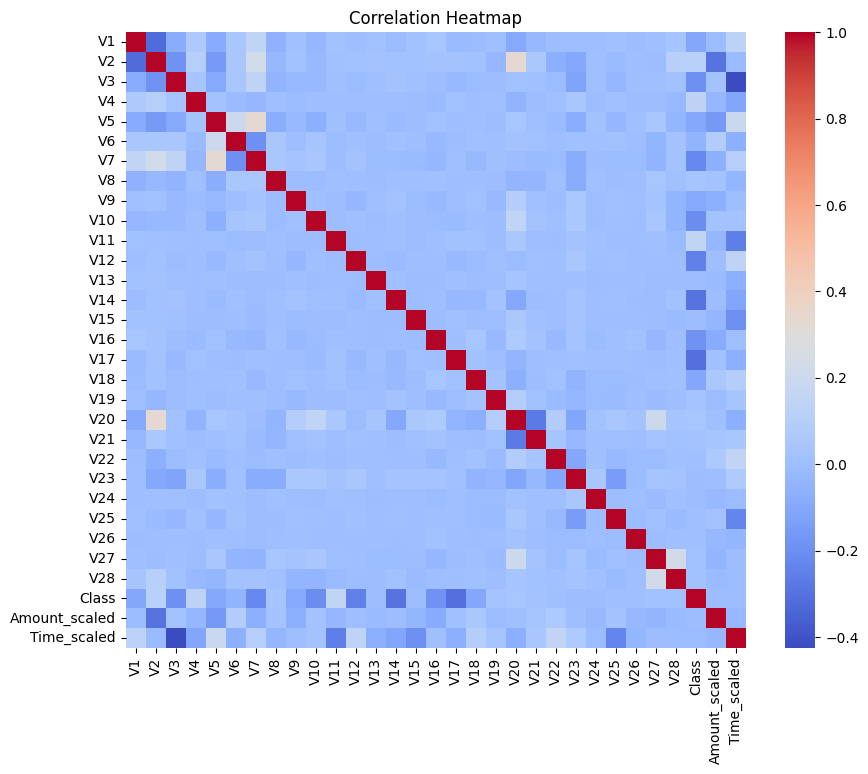


=== Scatter plot ===


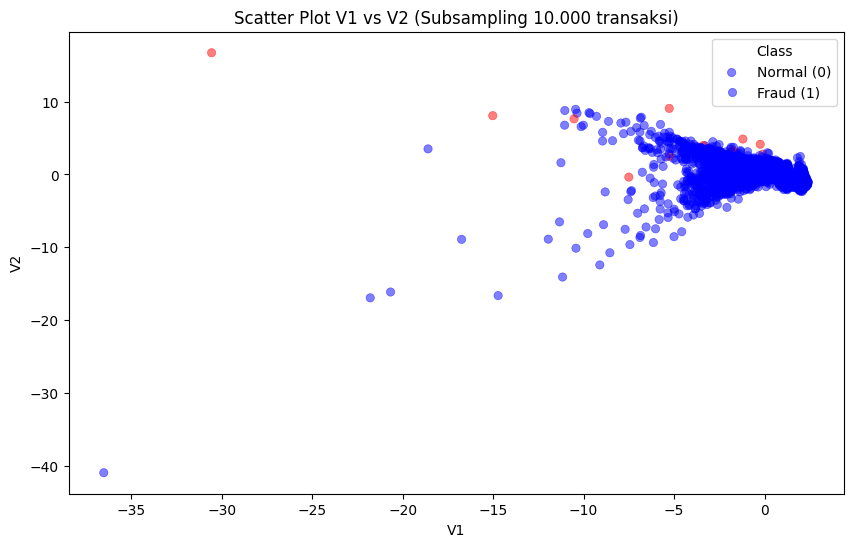

In [78]:
# VISUALISASI SETELAH PREPROCESSING

print("\n=== VISUALISASI SETELAH PREPROCESSING ===")

# Histogram setelah scaling
plt.figure()
sns.histplot(df['Amount_scaled'], bins=50)
plt.title("Distribusi Amount Setelah Scaling")
plt.show()


# Perbandingan Fraud dan normal
print("\n=== Perbandingan Fraud dan normal ===")

plt.figure()
sns.countplot(x='Class', data=df)
plt.title("Perbandingan Fraud(1) vs Normal(0)")
plt.show()


# HEATMAP KORELASI
print("\n=== HEATMAP ===")

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Scatter Plot
print('\n=== Scatter plot ===')
df_sample = df.sample(n=10000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='V1', y='V2', hue='Class',
                palette={0: 'blue', 1: 'red'}, alpha=0.5, edgecolor=None)
plt.title('Scatter Plot V1 vs V2 (Subsampling 10.000 transaksi)')
plt.legend(title='Class', labels=['Normal (0)', 'Fraud (1)'])
plt.show()



In [79]:
# OUTPUT AKHIR

print("\n=== DATA SIAP DIGUNAKAN ===")
print("Shape akhir:", df.shape)
print(df.head())


=== DATA SIAP DIGUNAKAN ===
Shape akhir: (252041, 31)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
5 -0.425966  0.960523  1.141109 -0.168252  0.420987 -0.029728  0.476201   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   
5  0.260314 -0.568671 -0.371407  ... -0.559825 -0.026398 -0.371427 -0.232794   

        V26  

In [80]:
# TEAM ASSIGNMENT 2
# Menampilkan rata-rata (mean), median, modus, standar deviasi, skewness, dan kurtosis untuk variabel numerik.

summary = pd.DataFrame({
    'mean': df.mean(),
    'median': df.median(),
    'mode': df.mode().iloc[0],
    'std': df.std(),
    'skewness': df.skew(),
    'kurtosis': df.kurtosis()
})

print(summary)

                       mean    median      mode       std   skewness  \
V1             1.011861e-01  0.037634  1.245674  1.807101  -2.448990   
V2             2.260759e-01  0.163929 -0.326668  1.287098  -1.780716   
V3             6.236232e-02  0.225750 -2.752041  1.462840  -2.054618   
V4            -2.201834e-02 -0.027494 -0.842316  1.392327   0.581494   
V5             1.183397e-01  0.021729 -0.562777  1.210319   0.898091   
V6            -6.043186e-02 -0.319513 -1.011073  1.263850   1.140694   
V7            -8.188773e-02  0.016757 -0.432126  1.026514  -4.809727   
V8             2.404737e-02  0.028929 -0.160211  1.139042  -6.856876   
V9             6.869212e-03 -0.046589  0.170362  1.077737   0.562612   
V10            2.267395e-02 -0.084312 -0.075186  1.072335   1.432921   
V11            4.495593e-03 -0.032355 -0.356749  1.018566   0.355185   
V12           -4.648848e-03  0.140445 -0.073460  0.999748  -2.203722   
V13            5.754233e-03 -0.007114 -0.517760  1.001305   0.05

In [81]:
# Menghitung korelasi antar fitur dalam dataset.
df_num = df.select_dtypes(include='number')

corr_matrix = df_num.corr(method='pearson')

print(corr_matrix)

                     V1        V2        V3        V4        V5        V6  \
V1             1.000000 -0.321002 -0.080836  0.066457 -0.087299  0.052236   
V2            -0.321002  1.000000 -0.180939  0.100865 -0.155741  0.047045   
V3            -0.080836 -0.180939  1.000000  0.031336 -0.093181  0.044466   
V4             0.066457  0.100865  0.031336  1.000000  0.023971 -0.018247   
V5            -0.087299 -0.155741 -0.093181  0.023971  1.000000  0.192364   
V6             0.052236  0.047045  0.044466 -0.018247  0.192364  1.000000   
V7             0.142568  0.230332  0.137099 -0.035734  0.331448 -0.197318   
V8            -0.057611 -0.029927 -0.050773  0.006777 -0.079738  0.052656   
V9             0.011742  0.018646 -0.023713 -0.011074 -0.022646  0.001415   
V10           -0.032787 -0.021190 -0.020969 -0.001208 -0.072240  0.033973   
V11            0.016916  0.010328  0.007431 -0.002658  0.006640 -0.011708   
V12           -0.001240  0.019031 -0.013242  0.000887 -0.020903  0.003166   

In [82]:
# Mengidentifikasi outliers dalam dataset menggunakan metode Boxplot atau Z-score.
Q1 = df['Amount_scaled'].quantile(0.25)
Q3 = df['Amount_scaled'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Sebelum Outliers dihapus:{df.shape}')

df = df[(df['Amount_scaled'] >= lower_bound) & (df['Amount_scaled'] <= upper_bound)]

print("Setelah outlier dihapus:", df.shape)

Sebelum Outliers dihapus:(252041, 31)
Setelah outlier dihapus: (233953, 31)


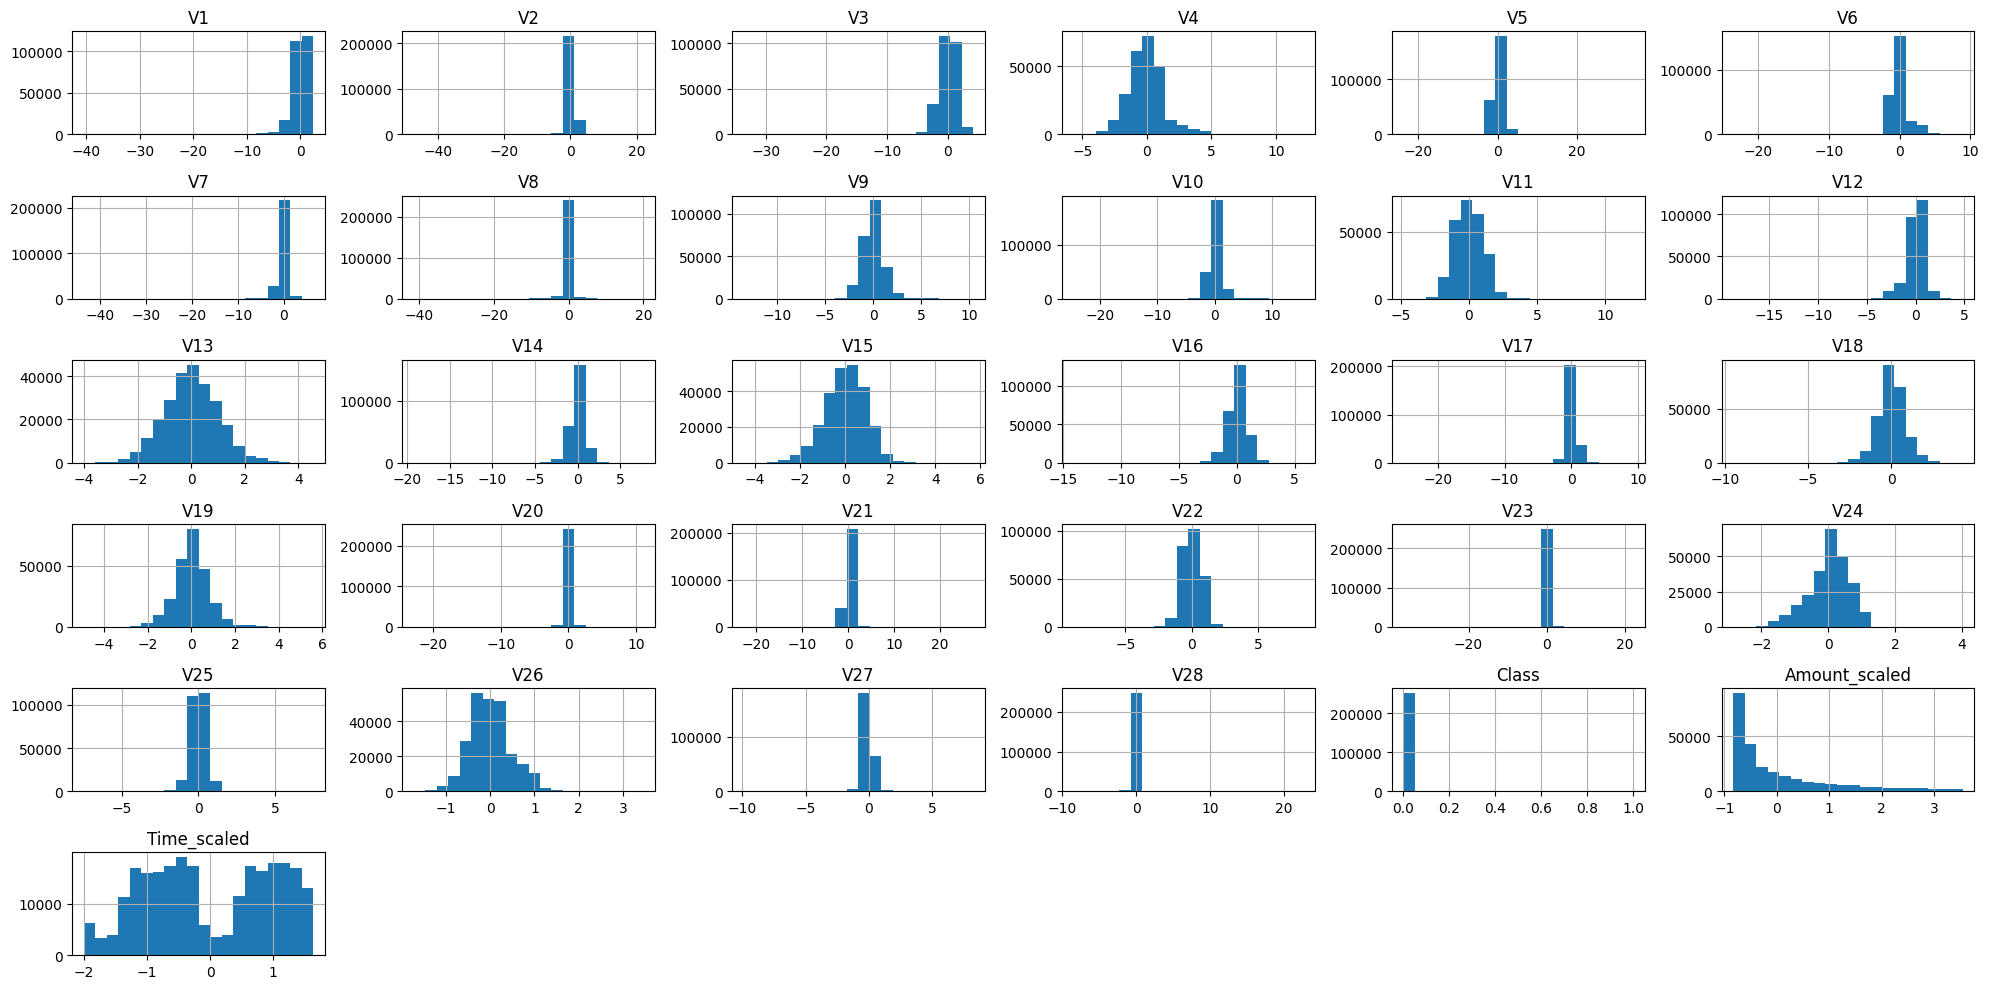

In [83]:
# Histogram untuk melihat distribusi fitur numerik.
df_num.hist(bins=20, figsize=(20, 10))
plt.tight_layout()
plt.show()

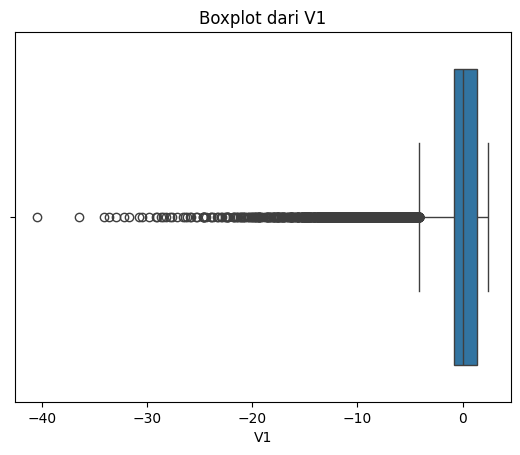

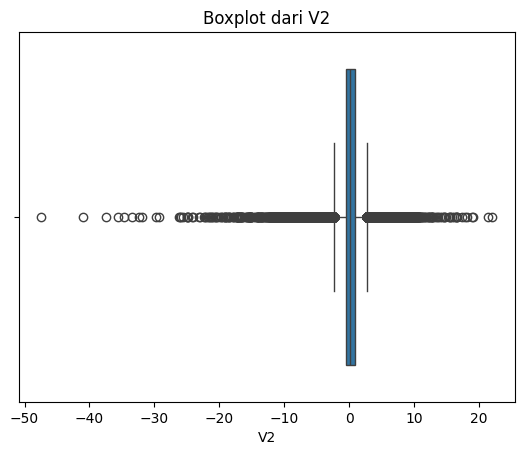

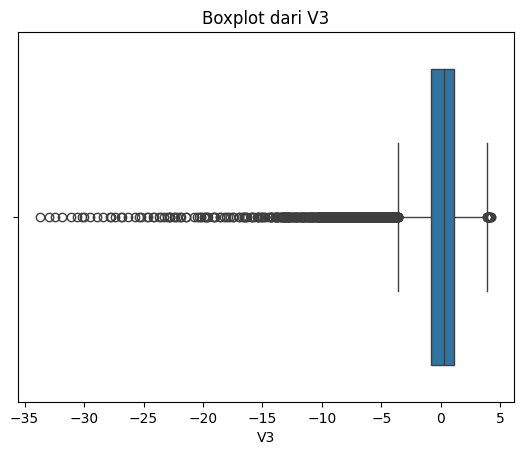

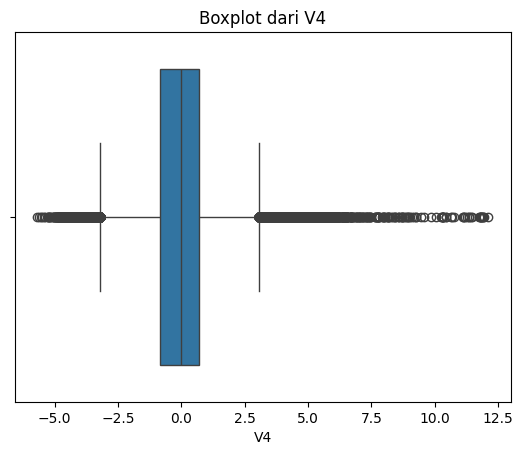

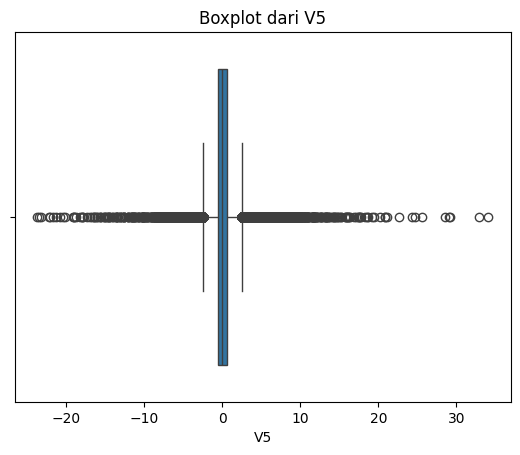

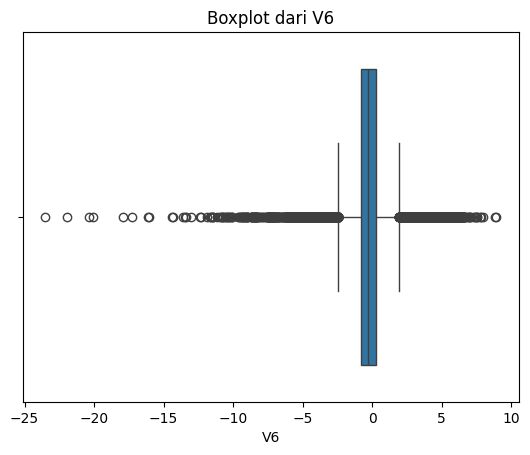

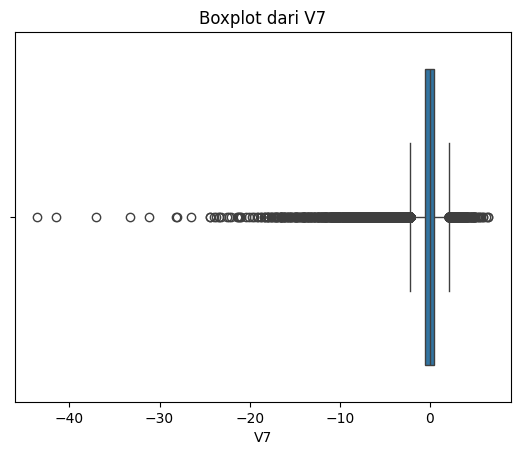

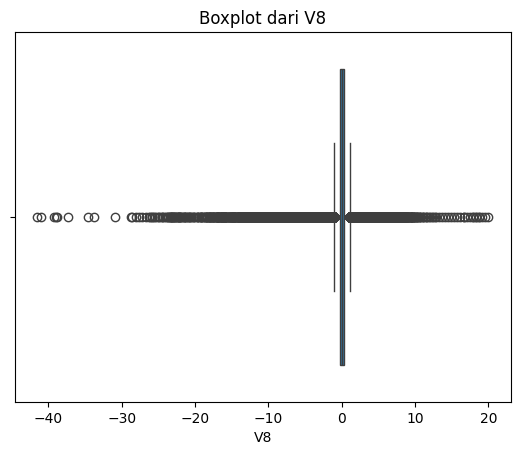

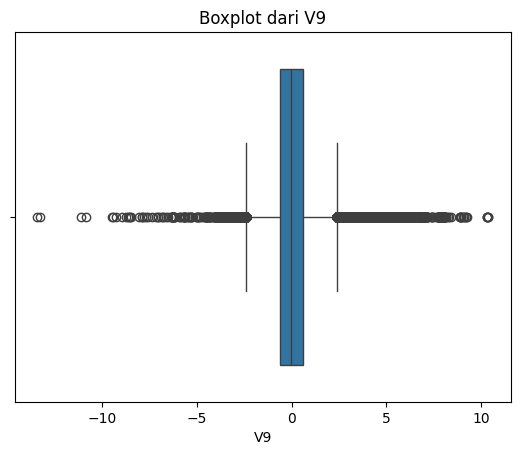

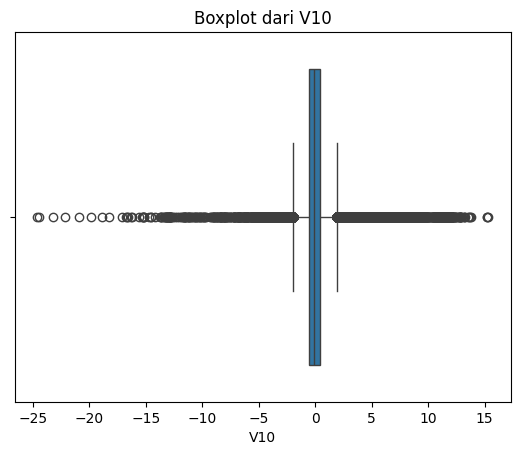

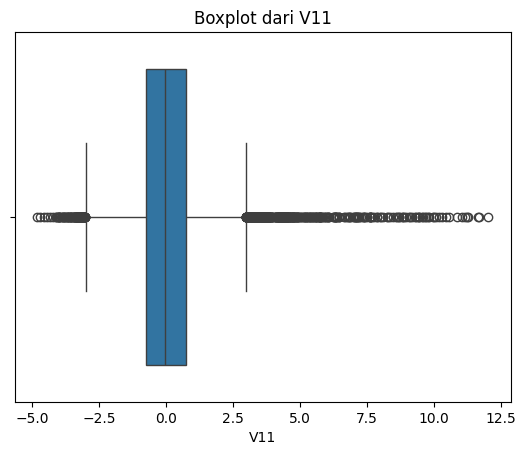

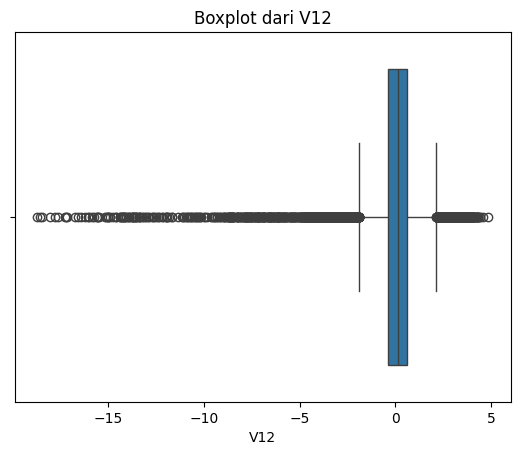

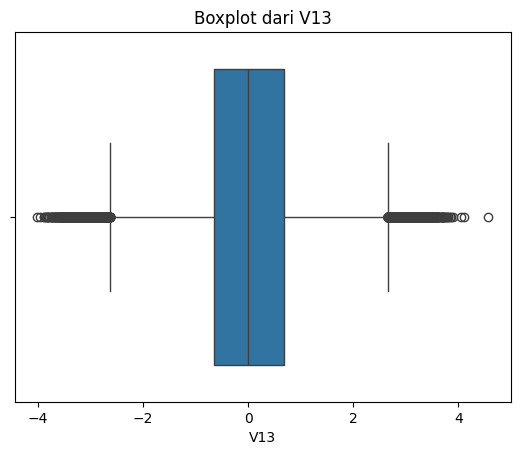

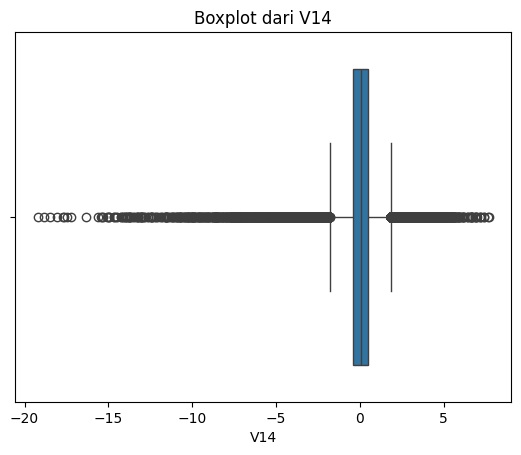

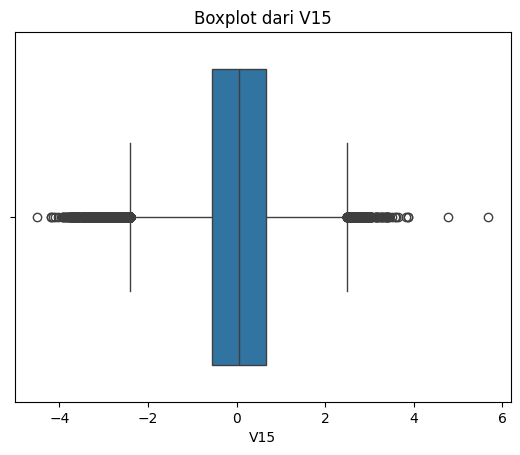

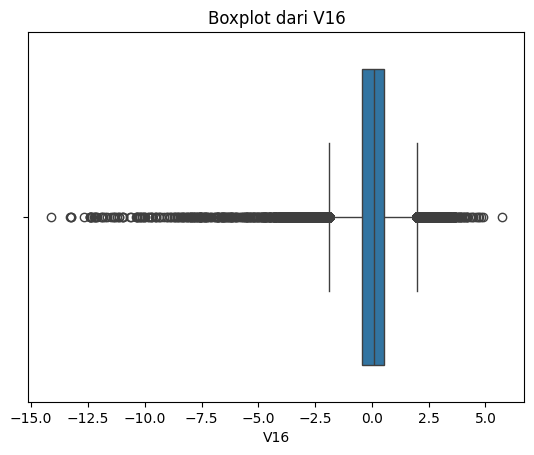

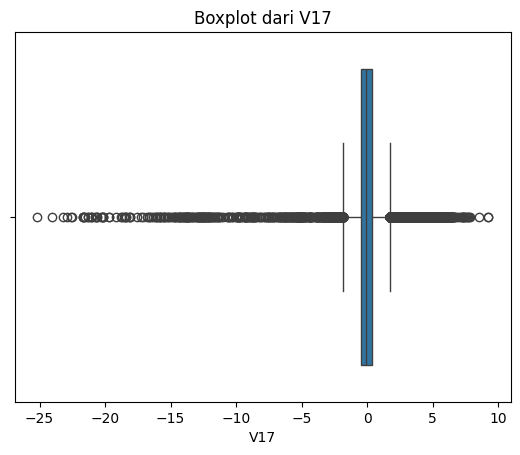

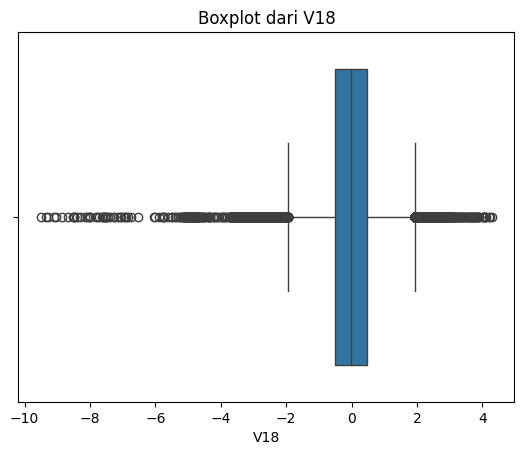

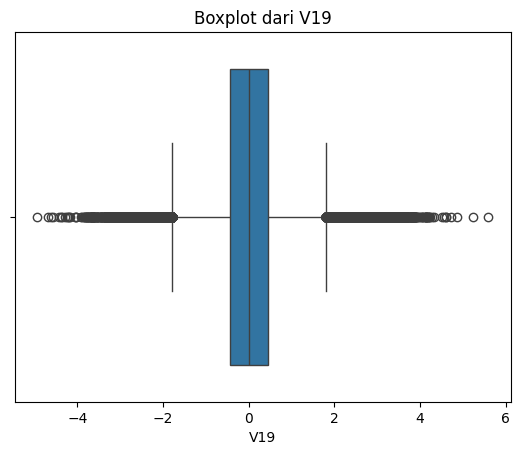

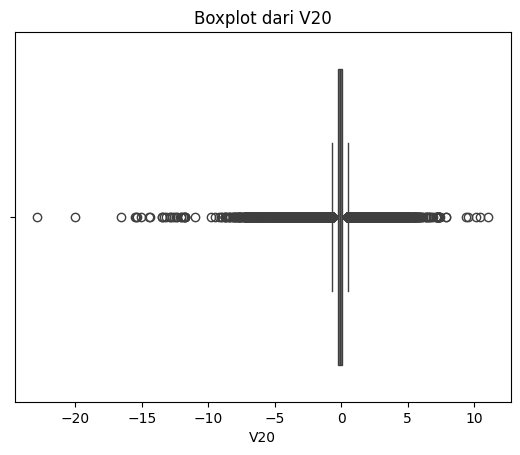

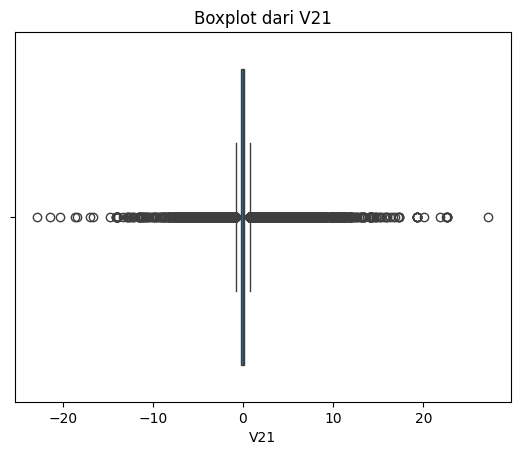

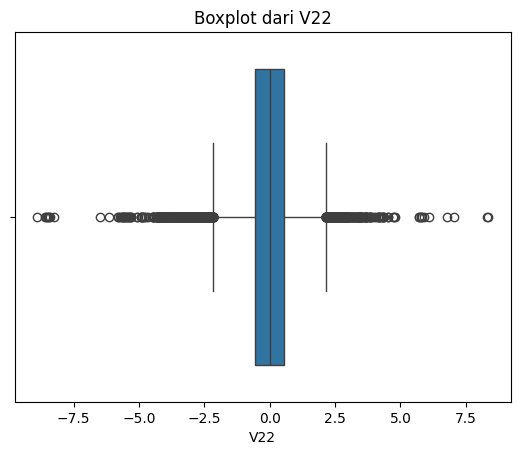

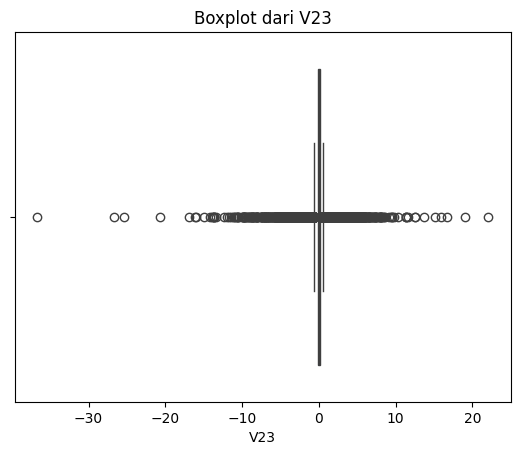

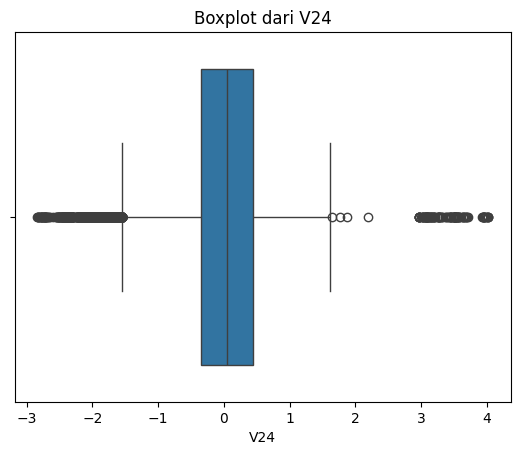

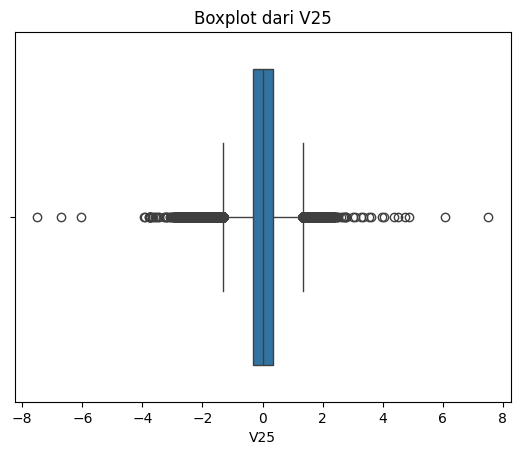

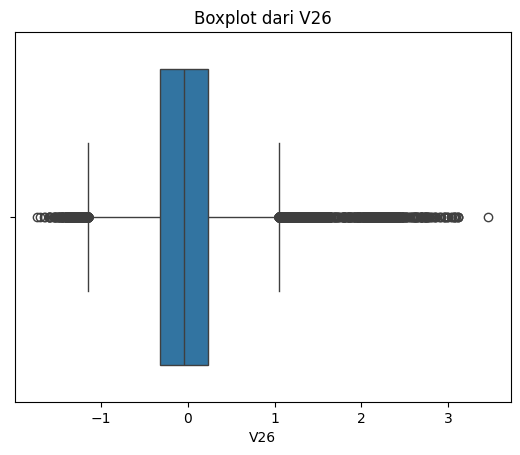

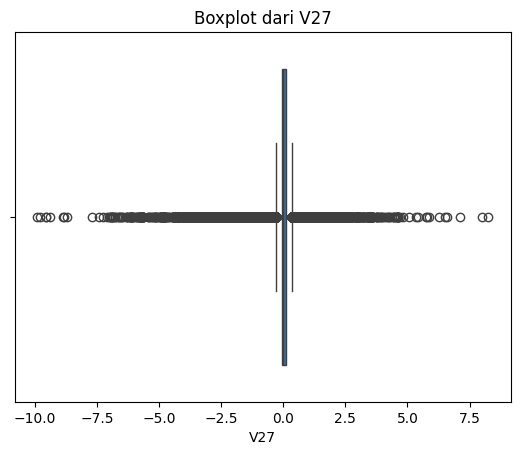

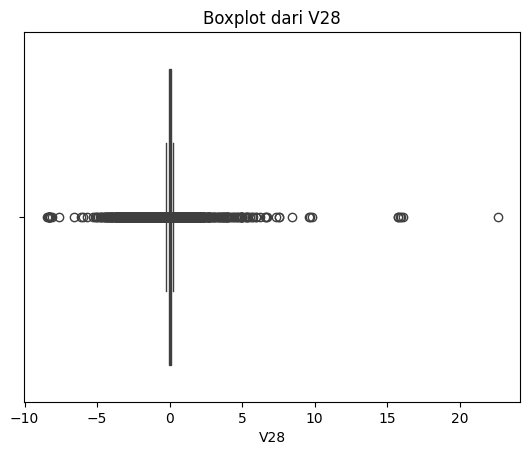

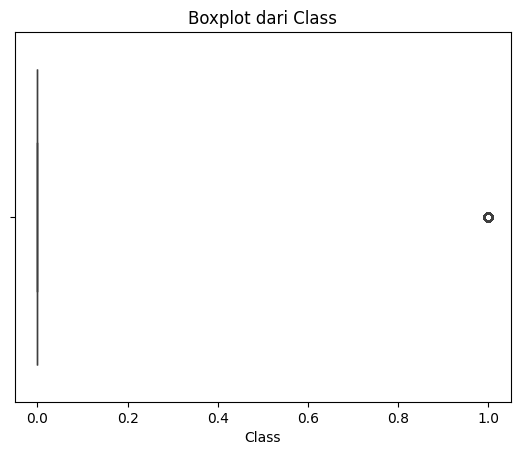

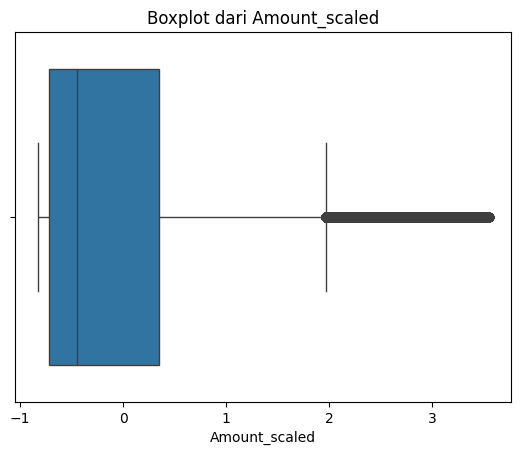

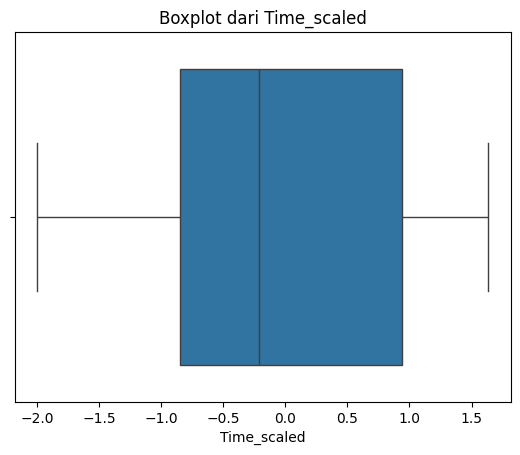

In [89]:
# Boxplot untuk melihat anomali atau outliers.
for col in df_num.columns:
    plt.figure()
    sns.boxplot(x=df_num[col])
    plt.title(f"Boxplot dari {col}")
    plt.show()

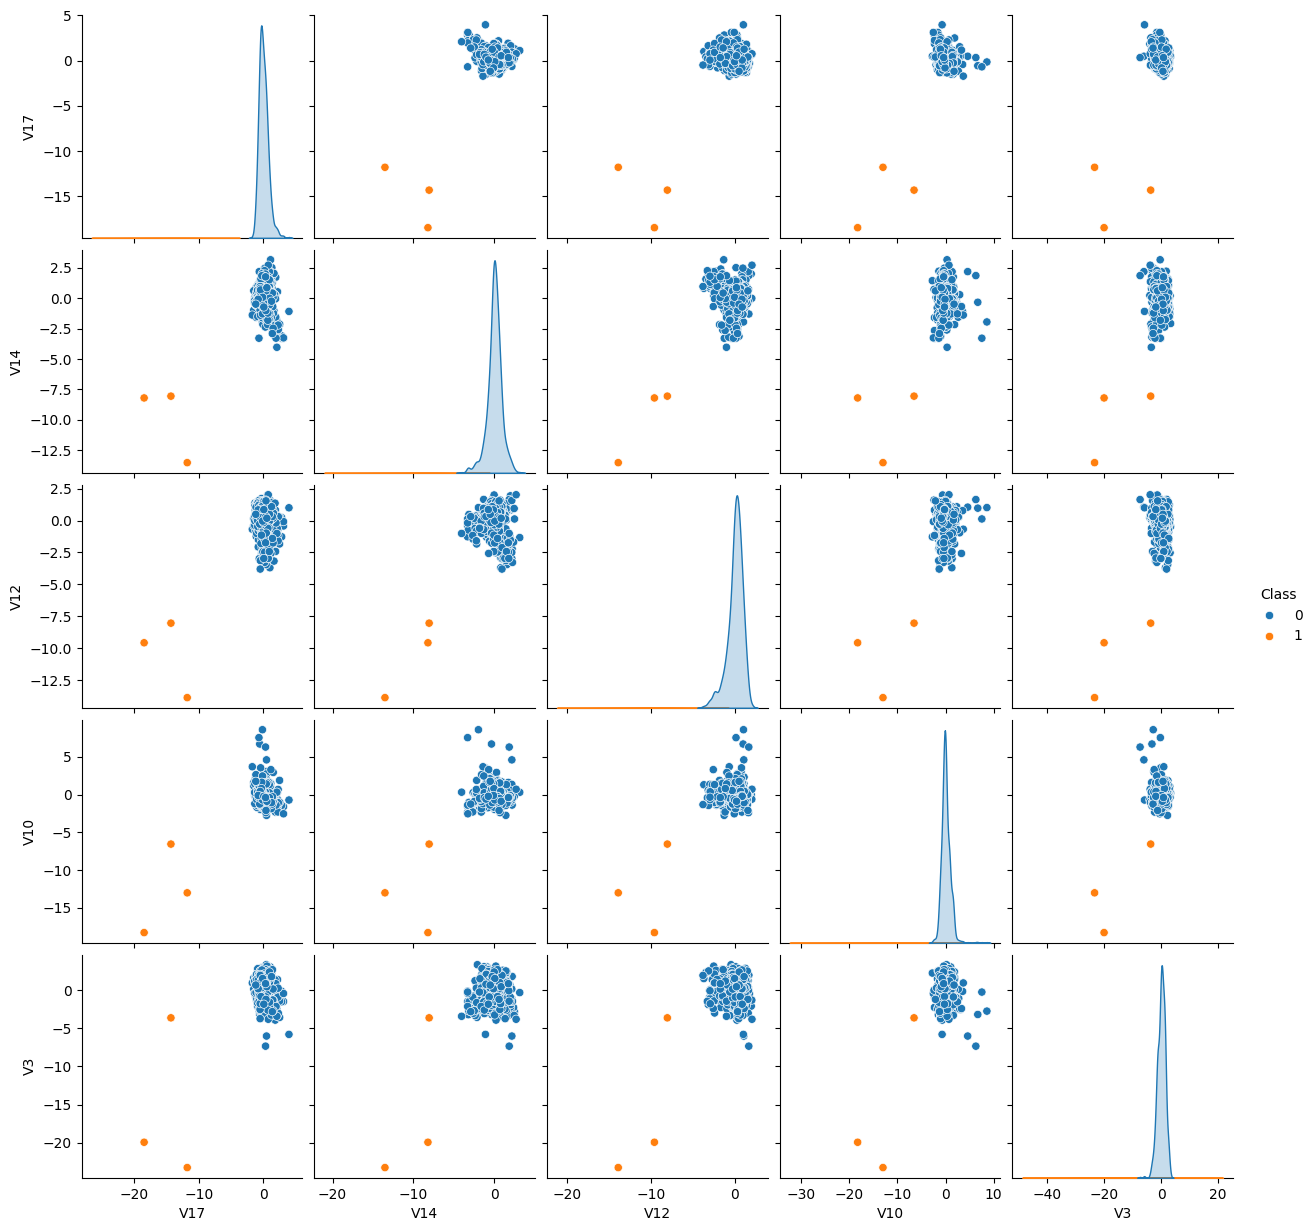

In [88]:
# Pair Plot atau Scatter Plot untuk melihat hubungan antar fitur numerik.
cols = ['V17','V14','V12','V10','V3','Class']
sns.pairplot(df[cols].sample(1000), hue='Class')

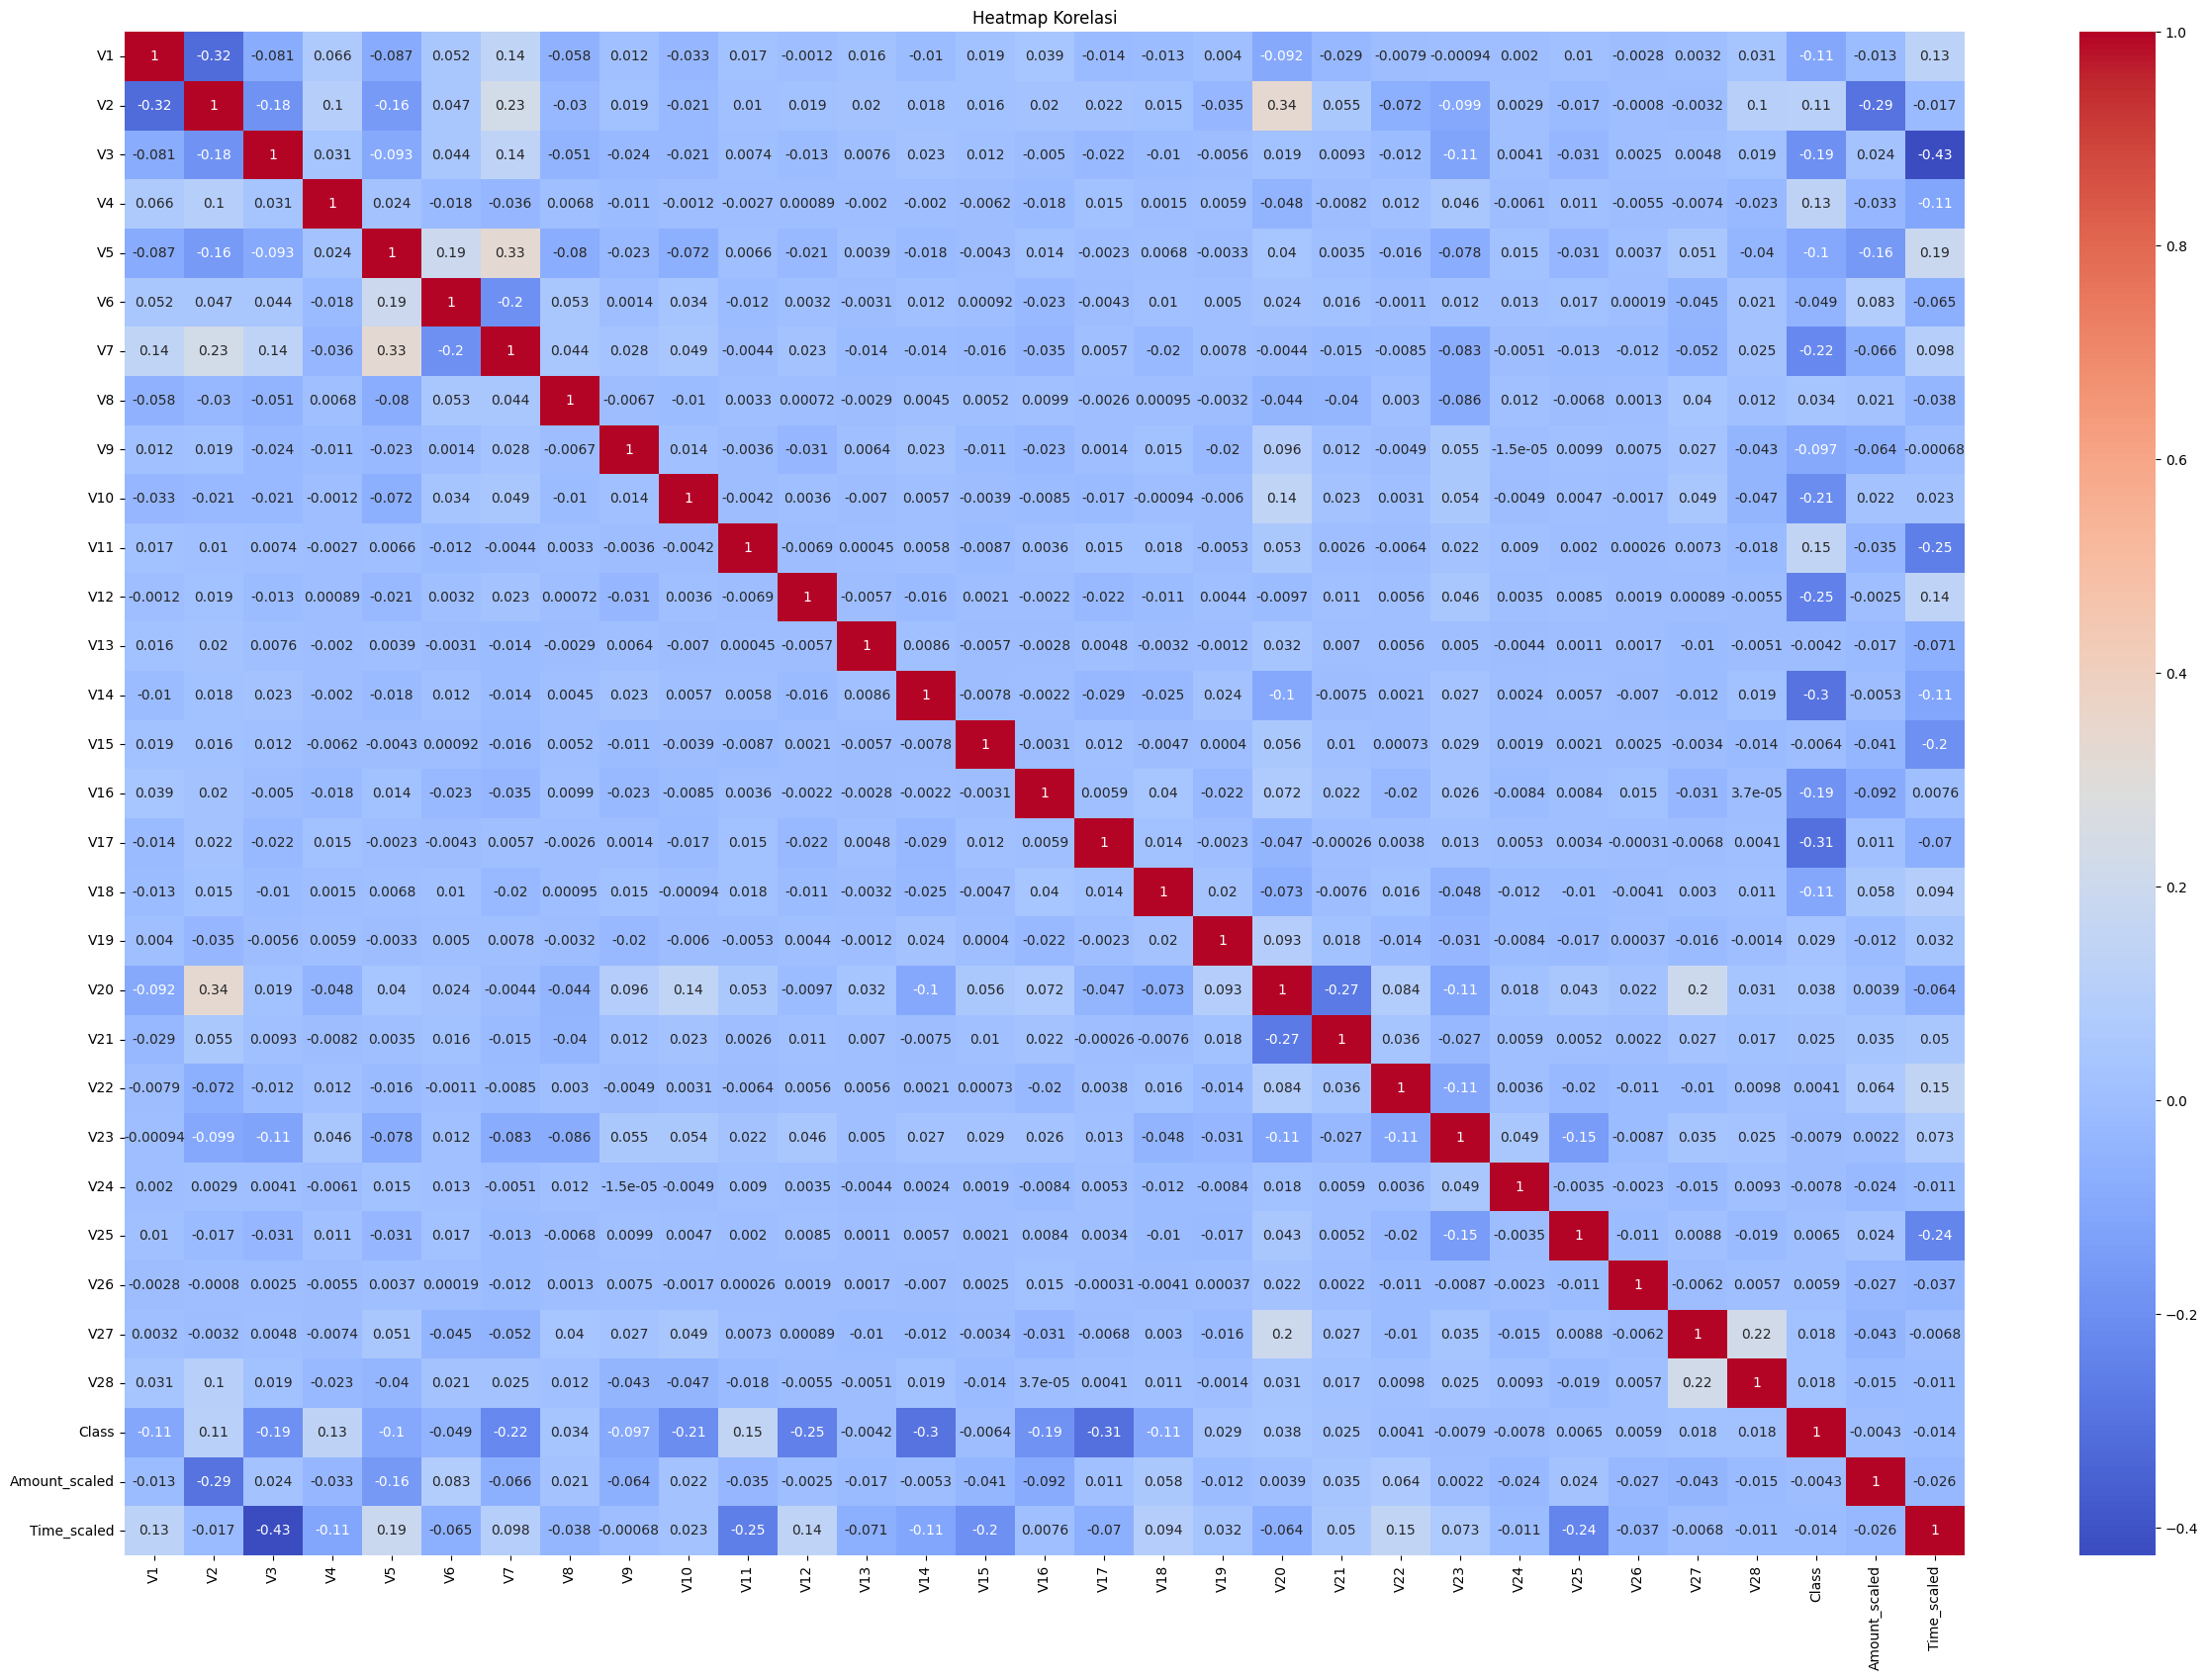

In [86]:
# Heatmap Korelasi untuk melihat hubungan antara variabel.
corr = df_num.corr()

plt.figure(figsize=(30, 20))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi")
plt.show()